In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Corridor Potential Movements on the V2 Aggregation — Three Routes (2022 layers)

Re-analysis of the corridor flows (steps 17 and 20) on the **new corridor aggregation** `Input/Corridor_TAZ_Agg_V2.xlsx`: 25 areas built from 174 TAZs, with three route orders:

- **T1** — Tirat Carmel → Haifa (trunk) → Tsomet Kiryat Ata → Kiryat Ata → Shefaram → Hamovil → **Nazareth** (17 areas);
- **T2** — the same trunk → **Kiryat Haim → Kiryat Bialik Center → Kiryon → Tsur Shalom** (16 areas);
- **T3** — the same trunk → **Kiryat Haim West → Kiryat Yam B+C → Kiryat Yam A → Savyoney Yam** (16 areas).

The twelve trunk areas (codes 201–212, order 1–12) are common to all three routes; the routes branch at Tsomet Kiryat Ata (212).

**Method.** Identical to step 17: the 2022 TAZ layers (car, bus, taxi-type, rail — `Output/ths2017/three_mode_2022/*_2022_taz.csv`) are aggregated to the 25 V2 areas; for each route, every OD pair with both ends on the route is assigned to every link between them in its direction of travel. Two directions: **up** = from Tirat Carmel towards the end of the branch (order increasing; the old "1 → 23"), **down** = towards Tirat Carmel. The peak-hour factors of step 20 (`peak_hour_factors_applied.csv`) are applied per layer and direction as before — car by direction (0.661 up / 0.626 down), bus and taxi-type the study-area factors (0.590 / 0.580), rail the bus factor. A fourth view treats the three routes as one **tree network**: every pair of the 25 areas has a unique path on the tree (trunk + branches), and cross-branch trips (e.g. Kiryat Ata → Kiryat Yam) load the trunk links they share, so the trunk profile counts every potential movement of the whole network.

**What these numbers are.** Three-hour (06:00–09:00) and peak-departure-hour totals of *potential movements* between line areas — trips that could traverse a link if every such trip used the line. Not passenger loads: no station access, no route choice against parallel services, no trips with one end off the line (§6o, §6r).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
IN = 'Output/ths2017/three_mode_2022'; OUT = 'Output/corridor_v2'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6, axis='y'); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

# ---- inputs: the 2022 TAZ layers and the V2 aggregation ----
def load_taz(name):
    m = pd.read_csv(f'{IN}/{name}_2022_taz.csv', index_col=0); m.index = m.index.astype(int); m.columns = m.columns.astype(int); return m
taz = {k: load_taz(k) for k in ['car', 'bus', 'taxi', 'rail']}
xl = pd.ExcelFile('Input/Corridor_TAZ_Agg_V2.xlsx')
areas = xl.parse('AreaCodes').set_index('AggCode'); key = xl.parse('TazAgg')
assert key['TAZ'].is_unique and key['TAZ'].isin(taz['car'].index).all(), 'every V2 TAZ must be in the 778-TAZ matrix'
area_of = key.set_index('TAZ')['AggCode']; names = areas['AggAreaName']
ROUTES = {r: list(areas[areas[f'Order_{r}'] > 0].sort_values(f'Order_{r}').index) for r in ['T1', 'T2', 'T3']}
TRUNK = [a for a in ROUTES['T1'] if all(a in ROUTES[r] for r in ROUTES)]
BRANCH = {r: [a for a in seq if a not in TRUNK] for r, seq in ROUTES.items()}
assert TRUNK == ROUTES['T2'][:len(TRUNK)] == ROUTES['T3'][:len(TRUNK)], 'the three routes must share the same trunk order'
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID')
legend = key.groupby('AggCode').agg(n_TAZs=('TAZ', 'size')).join(areas)
legend['population_2020'] = key.groupby('AggCode')['TAZ'].apply(lambda t: zon.reindex(t)['POPULATION'].fillna(0).sum())
legend['employment_2020'] = key.groupby('AggCode')['TAZ'].apply(lambda t: zon.reindex(t)['EMPL_TOT'].fillna(0).sum())
legend['segment'] = ['trunk' if a in TRUNK else 'branch ' + next(r for r in ROUTES if a in BRANCH[r]) for a in legend.index]
legend.to_csv(f'{OUT}/area_legend_v2.csv')
# ---- aggregate to the 25 areas ----
def to_area(m):
    t = m.loc[m.index.isin(area_of.index), m.columns.isin(area_of.index)]
    t = t.groupby(t.index.map(area_of)).sum().T.groupby(lambda c: area_of[c]).sum().T
    return t.reindex(index=legend.index, columns=legend.index).fillna(0)
A = {k: to_area(m) for k, m in taz.items()}
A['total'] = A['car'] + A['bus'] + A['taxi'] + A['rail']; A['transit'] = A['bus'] + A['rail']
for k, m in A.items(): m.to_csv(f'{OUT}/{k}_2022_area_v2.csv', float_format='%.3f')
for r, seq in ROUTES.items(): print(f"{r}: " + ' → '.join(f'{a} {names[a]}' for a in seq))
print(f"\n25 V2 areas, {len(key)} TAZs, population {legend['population_2020'].sum():,.0f}, employment {legend['employment_2020'].sum():,.0f} (2020)")
print("trips with both ends in the V2 areas, 2022, 06:00–09:00: " + ', '.join(f"{k} {A[k].values.sum():,.0f}" for k in ['car', 'bus', 'taxi', 'rail', 'transit', 'total']))
legend

T1: 201 TiratCarmel → 202 Matam-NeotPeres → 203 HofCarmel-NeveDavid → 204 Hecht-Shprintzak → 205 EinHayam → 206 BatGalim-KiryatEliezer → 207 Hamoshava → 208 LowerCity → 209 Namal-Giborim → 210 Hamifrats → 211 Bazan-Hutsot → 212 TsometKiryatAta → 213 KiryatAta North → 214 KiryatAta North-East → 215 Shefaram → 216 Hamovil → 217 Nazareth
T2: 201 TiratCarmel → 202 Matam-NeotPeres → 203 HofCarmel-NeveDavid → 204 Hecht-Shprintzak → 205 EinHayam → 206 BatGalim-KiryatEliezer → 207 Hamoshava → 208 LowerCity → 209 Namal-Giborim → 210 Hamifrats → 211 Bazan-Hutsot → 212 TsometKiryatAta → 104 KiryatHaim → 103 KiryatBialik Center → 102 Kiryon → 101 TsurShalom
T3: 201 TiratCarmel → 202 Matam-NeotPeres → 203 HofCarmel-NeveDavid → 204 Hecht-Shprintzak → 205 EinHayam → 206 BatGalim-KiryatEliezer → 207 Hamoshava → 208 LowerCity → 209 Namal-Giborim → 210 Hamifrats → 211 Bazan-Hutsot → 212 TsometKiryatAta → 304 KiryatHaim West → 303 KiryatYam B+C → 302 KiryatYam A → 301 SavyoneyYam

25 V2 areas, 174 TAZs, 

,n_TAZs,Order_T1,Order_T2,Order_T3,AggAreaName,population_2020,employment_2020,segment
AggCode,,,,,,,,
101,2,0,16,0,TsurShalom,12429,3359,branch T2
102,3,0,15,0,Kiryon,10633,5582,branch T2
103,9,0,14,0,KiryatBialik Center,32944,7897,branch T2
104,5,0,13,0,KiryatHaim,20686,8036,branch T2
201,14,1,1,1,TiratCarmel,26936,8424,trunk
202,10,2,2,2,Matam-NeotPeres,4211,20090,trunk
203,4,3,3,3,HofCarmel-NeveDavid,6867,2378,trunk
204,3,4,4,4,Hecht-Shprintzak,12074,1714,trunk
205,1,5,5,5,EinHayam,2048,139,trunk


## 1. Link flows per route — three-hour and peak-hour potential movements

In [3]:
phf = pd.read_csv(f'{IN}/peak_hour_factors_applied.csv')
FAC = {(r.layer.lower(), 'up' if r.direction == '1→23' else 'down'): r._3 for r in phf.itertuples()}   # column 3 = 'PHF3h applied'
FAC.update({('rail', d): FAC[('bus', d)] for d in ['up', 'down']})
LAYERS = ['car', 'bus', 'taxi', 'rail']

def link_flows(m, seq):
    """Directional link flows of a path: every (i, j) on seq loads the links between them. Returns (up, down) arrays and the internal total."""
    sub = m.reindex(index=seq, columns=seq).fillna(0).values; n = len(seq); up, down = np.zeros(n - 1), np.zeros(n - 1)
    for i in range(n):
        for j in range(n):
            if i < j: up[i:j] += sub[i, j]
            elif i > j: down[j:i] += sub[i, j]
    return up, down, sub.sum()

rows = []; internal = {}
for r, seq in ROUTES.items():
    for k in LAYERS:
        up, down, tot = link_flows(A[k], seq); internal[(r, k)] = tot
        for l in range(len(seq) - 1):
            for d, v in [('up', up[l]), ('down', down[l])]:
                rows.append({'route': r, 'link': l + 1, 'from_code': seq[l], 'to_code': seq[l + 1], 'from_area': names[seq[l]], 'to_area': names[seq[l + 1]],
                             'segment': 'trunk' if seq[l + 1] in TRUNK else 'branch', 'direction': d, 'layer': k, 'flow_3h': v, 'PHF3h': FAC[(k, d)], 'flow_peak_hour': v * FAC[(k, d)]})
lf = pd.DataFrame(rows)
tr = lf[lf['layer'].isin(['bus', 'rail'])].groupby(['route', 'link', 'from_code', 'to_code', 'from_area', 'to_area', 'segment', 'direction'], as_index=False)[['flow_3h', 'flow_peak_hour']].sum().assign(layer='transit')
tt = lf.groupby(['route', 'link', 'from_code', 'to_code', 'from_area', 'to_area', 'segment', 'direction'], as_index=False)[['flow_3h', 'flow_peak_hour']].sum().assign(layer='total')
lf = pd.concat([lf, tr, tt], ignore_index=True).sort_values(['route', 'layer', 'direction', 'link'])
lf.to_csv(f'{OUT}/corridor_v2_link_flows_long.csv', index=False, float_format='%.1f')
# wide table per route: one row per link, columns layer × direction (3 h and peak hour)
wide = lf.pivot_table(index=['route', 'link', 'from_area', 'to_area', 'segment'], columns=['layer', 'direction'], values=['flow_3h', 'flow_peak_hour']).round(1)
wide.columns = [f'{v.replace("flow_", "")} {k} {d}' for v, k, d in wide.columns]; wide = wide.reset_index()
wide.to_csv(f'{OUT}/corridor_v2_link_flows_wide.csv', index=False)
summary = []
for r, seq in ROUTES.items():
    for k in ['total', 'transit', 'car', 'bus', 'taxi']:
        s = lf[(lf.route == r) & (lf.layer == k)]
        for d in ['up', 'down']:
            sd = s[s.direction == d]; i = sd['flow_3h'].idxmax()
            summary.append({'route': r, 'layer': k, 'direction': d, 'route-internal trips (3 h)': internal[(r, k)] if k in LAYERS else sum(internal[(r, kk)] for kk in (['bus', 'rail'] if k == 'transit' else LAYERS)),
                            'busiest link': f"{sd.loc[i, 'from_area']} – {sd.loc[i, 'to_area']}", 'busiest link 3 h': sd.loc[i, 'flow_3h'], 'busiest link peak hour': sd.loc[i, 'flow_peak_hour'],
                            'branch max 3 h': sd[sd.segment == 'branch']['flow_3h'].max(), 'branch max peak hour': sd[sd.segment == 'branch']['flow_peak_hour'].max()})
summary = pd.DataFrame(summary); summary.to_csv(f'{OUT}/corridor_v2_route_summary.csv', index=False, float_format='%.0f')
print(summary[summary.layer.isin(['total', 'transit'])].round(0).to_string(index=False))

route   layer direction  route-internal trips (3 h)                          busiest link  busiest link 3 h  busiest link peak hour  branch max 3 h  branch max peak hour
   T1   total        up                    123906.0     EinHayam – BatGalim-KiryatEliezer            6878.0                  4331.0          1121.0                 739.0
   T1   total      down                    123906.0     TsometKiryatAta – KiryatAta North            5809.0                  3576.0          5809.0                3576.0
   T1 transit        up                     12546.0     EinHayam – BatGalim-KiryatEliezer            1379.0                   814.0            64.0                  38.0
   T1 transit      down                     12546.0 Matam-NeotPeres – HofCarmel-NeveDavid            1489.0                   879.0          1174.0                 693.0
   T2   total        up                     73964.0     EinHayam – BatGalim-KiryatEliezer            7036.0                  4422.0          2497.0   

In [4]:
show = wide[['route', 'link', 'from_area', 'to_area', 'segment', '3h total up', '3h total down', '3h transit up', '3h transit down', 'peak_hour transit up', 'peak_hour transit down', 'peak_hour total up', 'peak_hour total down']]
show.round(0)

,route,link,from_area,to_area,segment,3h total up,3h total down,3h transit up,3h transit down,peak_hour transit up,peak_hour transit down,peak_hour total up,peak_hour total down
0,T1,1,TiratCarmel,Matam-NeotPeres,trunk,5127.0,1315.0,536.0,189.0,316.0,111.0,3303.0,810.0
1,T1,2,Matam-NeotPeres,HofCarmel-NeveDavid,trunk,3711.0,5109.0,510.0,1489.0,301.0,879.0,2369.0,3124.0
2,T1,3,HofCarmel-NeveDavid,Hecht-Shprintzak,trunk,3953.0,5093.0,655.0,1464.0,387.0,864.0,2512.0,3113.0
3,T1,4,Hecht-Shprintzak,EinHayam,trunk,5574.0,4752.0,1200.0,1197.0,709.0,707.0,3510.0,2909.0
4,T1,5,EinHayam,BatGalim-KiryatEliezer,trunk,6878.0,4165.0,1379.0,1059.0,814.0,625.0,4331.0,2554.0
5,T1,6,BatGalim-KiryatEliezer,Hamoshava,trunk,5941.0,5737.0,1106.0,963.0,653.0,569.0,3786.0,3538.0
6,T1,7,Hamoshava,LowerCity,trunk,4980.0,4319.0,1016.0,1064.0,600.0,628.0,3138.0,2647.0
7,T1,8,LowerCity,Namal-Giborim,trunk,3872.0,4865.0,713.0,1322.0,421.0,781.0,2456.0,2978.0
8,T1,9,Namal-Giborim,Hamifrats,trunk,2987.0,4660.0,509.0,1161.0,301.0,685.0,1917.0,2855.0
9,T1,10,Hamifrats,Bazan-Hutsot,trunk,1914.0,4894.0,319.0,975.0,188.0,576.0,1223.0,3008.0


## 2. The three routes as one tree network — trunk links carry every branch's trips

In [5]:
# unique path on the tree between any two of the 25 areas: trunk order for trunk areas, branch order beyond Tsomet Kiryat Ata
pos = {}
for a in TRUNK: pos[a] = ('trunk', TRUNK.index(a))
for r, br in BRANCH.items():
    for i, a in enumerate(br): pos[a] = (r, len(TRUNK) + i)
LINKS = [(TRUNK[i], TRUNK[i + 1]) for i in range(len(TRUNK) - 1)] + [(([TRUNK[-1]] + br)[i], ([TRUNK[-1]] + br)[i + 1]) for br in BRANCH.values() for i in range(len(br))]
lpos = {l: i for i, l in enumerate(LINKS)}
def path_links(o, d):
    """Links of the tree path o → d as (link index, direction) with direction 'up' = away from Tirat Carmel."""
    if o == d: return []
    so, io = pos[o]; sd, id_ = pos[d]
    def to_root(a):  # sequence of areas from a down to Tirat Carmel (root)
        s, i = pos[a]; seq = [a]
        if s != 'trunk': seq += list(reversed(BRANCH[s][:i - len(TRUNK)])) + list(reversed(TRUNK))
        else: seq += list(reversed(TRUNK[:i]))
        return seq
    po, pd_ = to_root(o), to_root(d); common = next(a for a in po if a in set(pd_))
    up_part = list(reversed(pd_[:pd_.index(common) + 1]))       # common → d (moving up)
    down_part = po[:po.index(common) + 1]                      # o → common (moving down)
    out = [(lpos[(down_part[i + 1], down_part[i])], 'down') for i in range(len(down_part) - 1)]
    out += [(lpos[(up_part[i], up_part[i + 1])], 'up') for i in range(len(up_part) - 1)]
    return out
ALL = list(legend.index); net_rows = []
for k in LAYERS:
    F = {d: np.zeros(len(LINKS)) for d in ['up', 'down']}; sub = A[k].reindex(index=ALL, columns=ALL).values
    for i, o in enumerate(ALL):
        for j, d_ in enumerate(ALL):
            for li, dd in path_links(o, d_): F[dd][li] += sub[i, j]
    for li, (a, b) in enumerate(LINKS):
        for d in ['up', 'down']:
            net_rows.append({'link': li + 1, 'from_code': a, 'to_code': b, 'from_area': names[a], 'to_area': names[b], 'segment': 'trunk' if b in TRUNK else 'branch ' + pos[b][0], 'direction': d, 'layer': k, 'flow_3h': F[d][li], 'flow_peak_hour': F[d][li] * FAC[(k, d)]})
net = pd.DataFrame(net_rows)
g = ['link', 'from_code', 'to_code', 'from_area', 'to_area', 'segment', 'direction']
net = pd.concat([net, net[net.layer.isin(['bus', 'rail'])].groupby(g, as_index=False)[['flow_3h', 'flow_peak_hour']].sum().assign(layer='transit'), net.groupby(g, as_index=False)[['flow_3h', 'flow_peak_hour']].sum().assign(layer='total')], ignore_index=True)
net.to_csv(f'{OUT}/corridor_v2_network_link_flows.csv', index=False, float_format='%.1f')
# check: on every link the network flow is at least the single-route flow (a route only counts pairs with both ends on it; the network adds cross-branch trips)
chk = net.merge(lf, on=['from_code', 'to_code', 'direction', 'layer'], suffixes=('_net', '_route'))
assert (chk['flow_3h_net'] >= chk['flow_3h_route'] - 1e-6).all()
assert np.isclose(net[net.layer == 'total']['flow_3h'].sum(), sum(len(path_links(o, d)) * A['total'].loc[o, d] for o in ALL for d in ALL)), 'link loads must equal trips × links crossed'
netw = net.pivot_table(index=['link', 'from_area', 'to_area', 'segment'], columns=['layer', 'direction'], values=['flow_3h', 'flow_peak_hour']).round(0)
netw.columns = [f'{v.replace("flow_", "")} {k} {d}' for v, k, d in netw.columns]; netw = netw.reset_index()
print(f"network view: {A['total'].values.sum():,.0f} trips among the 25 areas; of these {sum(A['total'].reindex(index=BRANCH[r], columns=BRANCH[r2]).values.sum() for r in ROUTES for r2 in ROUTES if r != r2):,.0f} run between two different branches and load the trunk in neither single-route profile")
netw[['link', 'from_area', 'to_area', 'segment', '3h total up', '3h total down', '3h transit up', '3h transit down', 'peak_hour transit up', 'peak_hour transit down']]

network view: 184,106 trips among the 25 areas; of these 14,688 run between two different branches and load the trunk in neither single-route profile


,link,from_area,to_area,segment,3h total up,3h total down,3h transit up,3h transit down,peak_hour transit up,peak_hour transit down
0,1,TiratCarmel,Matam-NeotPeres,trunk,5247.0,1732.0,553.0,198.0,326.0,117.0
1,2,Matam-NeotPeres,HofCarmel-NeveDavid,trunk,3872.0,6581.0,546.0,1812.0,322.0,1070.0
2,3,HofCarmel-NeveDavid,Hecht-Shprintzak,trunk,4130.0,6605.0,706.0,1803.0,417.0,1065.0
3,4,Hecht-Shprintzak,EinHayam,trunk,5817.0,6313.0,1318.0,1585.0,778.0,936.0
4,5,EinHayam,BatGalim-KiryatEliezer,trunk,7183.0,5735.0,1518.0,1456.0,896.0,860.0
5,6,BatGalim-KiryatEliezer,Hamoshava,trunk,6370.0,9151.0,1303.0,1591.0,769.0,939.0
6,7,Hamoshava,LowerCity,trunk,5420.0,7767.0,1224.0,1726.0,723.0,1019.0
7,8,LowerCity,Namal-Giborim,trunk,4381.0,10030.0,936.0,2066.0,553.0,1220.0
8,9,Namal-Giborim,Hamifrats,trunk,3585.0,10638.0,759.0,2069.0,448.0,1222.0
9,10,Hamifrats,Bazan-Hutsot,trunk,2603.0,13214.0,590.0,2427.0,348.0,1433.0


## 3. Against the earlier 18-area profile (step 17 / 20)

In [6]:
old = pd.read_csv(f'{IN}/corridor_link_flows_peak_hour_2022.csv')
old_leg = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode')
old_key = pd.read_excel('Input/Submatrix_tazs.xlsx')
print(f"old aggregation: 28 areas / {len(old_key)} TAZs (18 on the line); V2: 25 areas / {len(key)} TAZs (17 / 16 / 16 on the routes)")
both = set(old_key.TAZ) & set(key.TAZ); print(f"TAZs in both: {len(both)}; only old: {len(set(old_key.TAZ) - both)}; only V2: {len(set(key.TAZ) - both)} (Nazareth city TAZs 19xx, Shefaram 40x, Neot Peres 16xx …)")
cmp = pd.DataFrame({'earlier 18-area line': {'busiest transit link 3 h up': old['transit 3h 1→23'].max(), 'busiest transit link 3 h down': old['transit 3h 23→1'].max(), 'busiest transit link peak hour up': old['transit peak 1→23'].max(), 'busiest transit link peak hour down': old['transit peak 23→1'].max(),
                                              'busiest total link 3 h up': old['total 3h 1→23'].max(), 'busiest total link 3 h down': old['total 3h 23→1'].max(), 'busiest total link peak hour up': old['total peak 1→23'].max(), 'busiest total link peak hour down': old['total peak 23→1'].max()}})
for r in ROUTES:
    s = lf[lf.route == r]
    cmp[f'V2 route {r}'] = {f'busiest {k} link {m} {d}': s[(s.layer == k) & (s.direction == d)][('flow_3h' if m == '3 h' else 'flow_peak_hour')].max() for k in ['transit', 'total'] for m in ['3 h', 'peak hour'] for d in ['up', 'down']}
s = net; cmp['V2 tree network'] = {f'busiest {k} link {m} {d}': s[(s.layer == k) & (s.direction == d)][('flow_3h' if m == '3 h' else 'flow_peak_hour')].max() for k in ['transit', 'total'] for m in ['3 h', 'peak hour'] for d in ['up', 'down']}
cmp.round(0).to_csv(f'{OUT}/corridor_v2_vs_earlier_profile.csv'); cmp.round(0)

old aggregation: 28 areas / 205 TAZs (18 on the line); V2: 25 areas / 174 TAZs (17 / 16 / 16 on the routes)
TAZs in both: 143; only old: 62; only V2: 31 (Nazareth city TAZs 19xx, Shefaram 40x, Neot Peres 16xx …)


,earlier 18-area line,V2 route T1,V2 route T2,V2 route T3,V2 tree network
busiest transit link 3 h up,1661.0,1379.0,1391.0,1437.0,1518.0
busiest transit link 3 h down,1650.0,1489.0,1629.0,1410.0,2898.0
busiest transit link peak hour up,981.0,814.0,821.0,848.0,896.0
busiest transit link peak hour down,974.0,879.0,962.0,833.0,1711.0
busiest total link 3 h up,7326.0,6878.0,7036.0,6956.0,9559.0
busiest total link 3 h down,6847.0,5809.0,10144.0,4896.0,16231.0
busiest total link peak hour up,4609.0,4331.0,4422.0,4378.0,6193.0
busiest total link peak hour down,4205.0,3576.0,6239.0,2988.0,9956.0


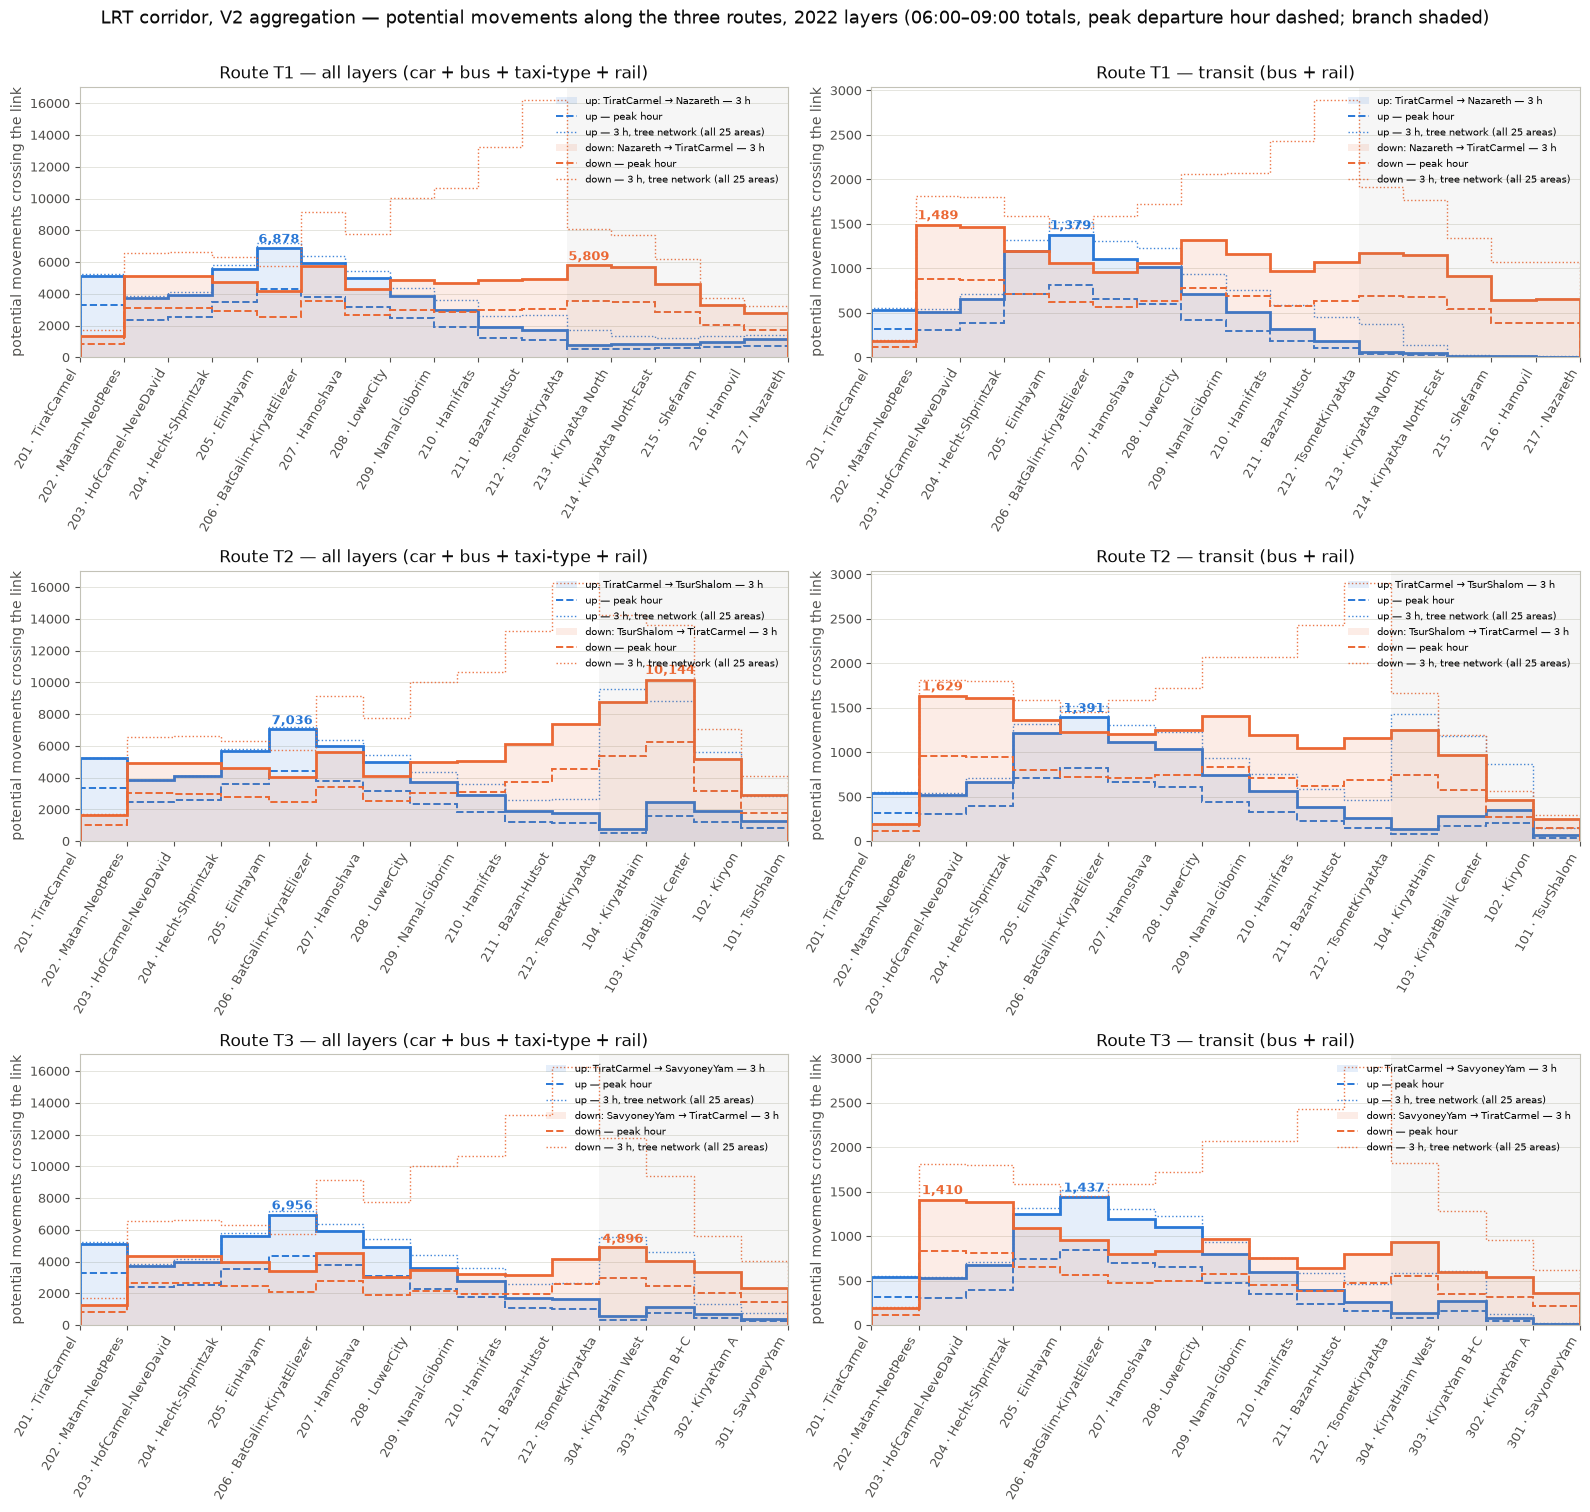

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15), facecolor='white')
for i, (r, seq) in enumerate(ROUTES.items()):
    for j, (k, lab) in enumerate([('total', 'all layers (car + bus + taxi-type + rail)'), ('transit', 'transit (bus + rail)')]):
        ax = axes[i, j]; x = np.arange(len(seq)); s = lf[(lf.route == r) & (lf.layer == k)]; n = net[net.layer == k]
        for d, color, dl in [('up', BLUE, f'up: {names[seq[0]]} → {names[seq[-1]]}'), ('down', ORANGE, f'down: {names[seq[-1]]} → {names[seq[0]]}')]:
            y3 = s[s.direction == d].sort_values('link')['flow_3h'].values; yp = s[s.direction == d].sort_values('link')['flow_peak_hour'].values
            ax.stairs(y3, x, color=color, linewidth=2, label=f'{dl} — 3 h', baseline=0, fill=True, alpha=0.12); ax.stairs(y3, x, color=color, linewidth=2)
            ax.stairs(yp, x, color=color, linewidth=1.4, linestyle='--', label=f'{d} — peak hour')
            yn = np.array([n[(n.direction == d) & (n.from_code == a) & (n.to_code == b)]['flow_3h'].iloc[0] for a, b in zip(seq[:-1], seq[1:])])
            ax.stairs(yn, x, color=color, linewidth=1, linestyle=':', alpha=0.9, label=f'{d} — 3 h, tree network (all 25 areas)')
            kk = int(np.argmax(y3)); ax.text(kk + 0.5, y3[kk] * 1.02, f'{y3[kk]:,.0f}', ha='center', va='bottom', color=color, fontsize=9, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels([f'{a} · {names[a]}' for a in seq], rotation=60, ha='right', fontsize=8, color=INK2); ax.set_xlim(0, len(seq) - 1)
        ax.axvspan(len(TRUNK) - 1, len(seq) - 1, color=MUTED, alpha=0.07, lw=0)
        style_ax(ax, f'Route {r} — {lab}', None, 'potential movements crossing the link'); ax.legend(frameon=False, fontsize=7.5, loc='upper right')
fig.suptitle('LRT corridor, V2 aggregation — potential movements along the three routes, 2022 layers (06:00–09:00 totals, peak departure hour dashed; branch shaded)', color=INK, fontsize=13, y=1.005)
plt.tight_layout(); fig.savefig('Output/figures/corridor_v2_route_profiles_2022.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## Findings

- **Coverage of the V2 aggregation.** 25 areas from 174 TAZs (492,000 residents, 221,000 jobs in 2020) — 143 TAZs shared with the earlier 28-area set, 62 old TAZs dropped (Hadar Carmel, Neve Yosef, Kiryat Nahum, Kiryat Ata East, Adi / Alon Hagalil / Tzipori, the influence areas) and 31 added (the whole of Nazareth city, 38 TAZs and 198,000 residents against the old 15-TAZ "Nazareth Area"; Shefaram; the Neot Peres TAZs). Trips with both ends in the 25 areas, 2022, 06:00–09:00: 184,106 (car 156,944, bus 18,788, taxi-type 8,323, rail 51). The totals are therefore not one-to-one comparable with steps 17 / 20; the Haifa-segment link values are.
- **Route T1 (Nazareth).** 123,906 route-internal trips, 12,546 transit. Busiest transit link on the trunk: Ein Hayam – Bat Galim-Kiryat Eliezer, 1,379 up (peak hour 814); Matam-Neot Peres – Hof Carmel-Neve David, 1,489 down (879). The branch is one-directional in the morning: Tsomet Kiryat Ata – Kiryat Ata North carries 5,809 down (towards Haifa; 1,174 transit, share 20 %) against 785 up (64 transit). The Shefaram – Hamovil – Nazareth links carry 650–920 transit trips down with a transit share of 20–23 % — the highest in the set, all of it Nazareth / Shefaram residents bound for Haifa.
- **Route T2 (Krayot via Kiryat Haim – Kiryat Bialik – Kiryon).** 73,964 route-internal trips, 7,711 transit. The busiest link of any route is on this branch: Kiryat Haim – Kiryat Bialik Center, 10,144 down (peak hour 6,239) against 2,497 up — more than any trunk link — but its transit share is 10 % (966 transit down). On the trunk the busiest transit link is Matam-Neot Peres – Hof Carmel-Neve David, 1,629 down (962).
- **Route T3 (Kiryat Yam).** 55,519 route-internal trips, 7,054 transit; branch peak Tsomet Kiryat Ata – Kiryat Haim West, 4,896 down (2,988 peak hour; 936 transit, share 19 %).
- **The tree network is where the trunk east of Hamifrats fills up.** Loading every pair of the 25 areas on its unique tree path, the trunk link Bazan-Hutsot – Tsomet Kiryat Ata carries 16,231 down (peak hour 9,956) and 2,898 transit (1,711) — the inflow of all three branches at once, against 4,958 / 1,075 on the same link in the T1 profile alone. The Haifa-side trunk (Tirat Carmel – Bat Galim) changes little between the views (7,183 up on Ein Hayam – Bat Galim in the network view against 6,878–7,036 per route). The 14,688 branch-to-branch trips (8 % of the 25-area total) load only the branch links and the Tsomet Kiryat Ata node, not the trunk.
- **Direction.** Down (towards Tirat Carmel, i.e. into Haifa from the east and north) dominates every link east of Bat Galim in the morning; up dominates only the Tirat Carmel – Ein Hayam segment, where Tirat Carmel's residents head into the city. Transit share of link flow: 17–33 % down and 10–22 % up on the trunk.
- **Against the earlier 18-area profile.** Busiest transit link, three hours: earlier 1,661 up / 1,650 down; per V2 route 1,379–1,437 up / 1,410–1,629 down; network 1,518 up / 2,898 down. The Haifa-segment values agree within the reaggregation (Bat Galim and Kiryat Eliezer merged, Matam and Neot Peres merged, Hecht-Shprintzak new); the down-direction network value is higher because the three branches now feed the same trunk.
- **Caveats.** Same as §6o / §6r: potential movements, not loads; three-hour and peak-departure-hour; no station access, no route choice, no off-line trips. In addition, the car peak-hour factors by direction were estimated on the earlier 18-area sequence and are applied here unchanged; the two-thirds of the T2 / T3 branch flow that is car (share 85–90 %) is the market an LRT would have to win, not one it has.